In [ ]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json
url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
}


In [ ]:

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

#NOTE:
# I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
# Into the Anaconda Prompt to change this to allow to pull data

# If that didn't work try using the local host URL as shown in the video
type(data)


In [ ]:
import pandas as pd


#This allows you to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
#This normalizes the data and makes it all pretty in a dataframe


In [ ]:
df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

In [ ]:
def api_runner():
  global df
  url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
  parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
  }
  headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
  }

  session = Session()
  session.headers.update(headers)

  try:
    response = session.get(url, params=parameters)
    data = json.loads(response.text)
    df2 = pd.json_normalize(data['data'])
    df2['timestamp'] = pd.to_datetime('now')
    df = pd.concat([df, df2], ignore_index=True)
  except (ConnectionError, Timeout, TooManyRedirects) as e:
    print(e)
  if not os.path.isfile(r'crypto_data.csv'):
    df.to_csv(r'crypto_data.csv', header='column_names', index=False)
  else:   
    df2.to_csv(r'crypto_data.csv', mode='a', header=False, index=False)

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 40 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   id                                  60 non-null     int64         
 1   name                                60 non-null     str           
 2   symbol                              60 non-null     str           
 3   slug                                60 non-null     str           
 4   infinite_supply                     60 non-null     bool          
 5   circulating_supply                  60 non-null     float64       
 6   total_supply                        60 non-null     float64       
 7   max_supply                          24 non-null     float64       
 8   date_added                          60 non-null     str           
 9   num_market_pairs                    60 non-null     int64         
 10  cmc_rank                            60 

In [19]:
import os 
from time import time, sleep

for i in range(333):
    api_runner()
    print(f'API Runner has run {i} times')
    sleep(60) # Sleep for 60 seconds before running the API again
exit()

API Runner has run 1 times
API Runner has run 2 times


KeyboardInterrupt: 

In [ ]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)


In [20]:
df.columns

Index(['id', 'name', 'symbol', 'slug', 'infinite_supply', 'circulating_supply',
       'total_supply', 'max_supply', 'date_added', 'num_market_pairs',
       'cmc_rank', 'last_updated', 'tvl_ratio', 'platform',
       'self_reported_circulating_supply', 'self_reported_market_cap',
       'minted_market_cap', 'tags', 'quote.USD.price', 'quote.USD.volume_24h',
       'quote.USD.cex_volume_24h', 'quote.USD.dex_volume_24h',
       'quote.USD.volume_change_24h', 'quote.USD.percent_change_1h',
       'quote.USD.percent_change_24h', 'quote.USD.percent_change_7d',
       'quote.USD.percent_change_30d', 'quote.USD.percent_change_60d',
       'quote.USD.percent_change_90d', 'quote.USD.market_cap',
       'quote.USD.market_cap_dominance', 'quote.USD.fully_diluted_market_cap',
       'quote.USD.tvl', 'quote.USD.last_updated', 'platform.id',
       'platform.slug', 'platform.name', 'platform.symbol',
       'platform.token_address', 'timestamp'],
      dtype='str')

In [24]:
df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.470076,0.043498,-2.261627,-14.909830,-17.688353,-8.582877
Ethereum,0.235532,0.300411,1.014599,-15.949183,-26.173783,-18.734436
Tether USDt,-0.000640,0.004589,-0.056114,-0.003409,-0.132686,-0.089932
BNB,0.155753,0.310381,-4.316303,-9.085554,-7.277178,-5.961179
USDC,-0.002994,0.012059,0.007174,0.001886,0.012125,-0.014671
XRP,0.429080,-0.718720,-4.053356,-14.872925,-19.940634,-19.455966
Solana,0.600261,1.263390,4.250890,-12.239899,-13.958489,-17.883101
TRON,0.023063,0.564892,2.253911,-9.260252,-0.279150,5.705718
Hyperliquid,0.576972,-4.356002,1.859816,19.329983,61.131196,73.548949


In [25]:
df4 = df3.stack()
df4

name                                      
Bitcoin       quote.USD.percent_change_1h      0.470076
              quote.USD.percent_change_24h     0.043498
              quote.USD.percent_change_7d     -2.261627
              quote.USD.percent_change_30d   -14.909830
              quote.USD.percent_change_60d   -17.688353
              quote.USD.percent_change_90d    -8.582877
Ethereum      quote.USD.percent_change_1h      0.235532
              quote.USD.percent_change_24h     0.300411
              quote.USD.percent_change_7d      1.014599
              quote.USD.percent_change_30d   -15.949183
              quote.USD.percent_change_60d   -26.173783
              quote.USD.percent_change_90d   -18.734436
Tether USDt   quote.USD.percent_change_1h     -0.000640
              quote.USD.percent_change_24h     0.004589
              quote.USD.percent_change_7d     -0.056114
              quote.USD.percent_change_30d    -0.003409
              quote.USD.percent_change_60d    -0.132686
     

In [26]:
df5 = df4.to_frame(name='values')
df5

values
name                                                
Bitcoin      quote.USD.percent_change_1h    0.470076
             quote.USD.percent_change_24h   0.043498
             quote.USD.percent_change_7d   -2.261627
             quote.USD.percent_change_30d -14.909830
             quote.USD.percent_change_60d -17.688353
             quote.USD.percent_change_90d  -8.582877
Ethereum     quote.USD.percent_change_1h    0.235532
             quote.USD.percent_change_24h   0.300411
             quote.USD.percent_change_7d    1.014599
             quote.USD.percent_change_30d -15.949183
             quote.USD.percent_change_60d -26.173783
             quote.USD.percent_change_90d -18.734436
Tether USDt  quote.USD.percent_change_1h   -0.000640
             quote.USD.percent_change_24h   0.004589
             quote.USD.percent_change_7d   -0.056114
             quote.USD.percent_change_30d  -0.003409
             quote.USD.percent_change_60d  -0.132686
             quote.USD.percent_change_90d  -0.089932
BNB          quote.USD.percent_change_1h    0.155753
             quote.USD.percent_change_24h   0.310381
             quote.USD.percent_change_7d   -4.316303
             quote.USD.percent_change_30d  -9.085554
             quote.USD.percent_change_60d  -7.277178
             quote.USD.percent_change_90d  -5.961179
USDC         quote.USD.percent_change_1h   -0.002994
             quote.USD.percent_change_24h   0.012059
             quote.USD.percent_change_7d    0.007174
             quote.USD.percent_change_30d   0.001886
             quote.USD.percent_change_60d   0.012125
             quote.USD.percent_change_90d  -0.014671
XRP          quote.USD.percent_change_1h    0.429080
             quote.USD.percent_change_24h  -0.718720
             quote.USD.percent_change_7d   -4.053356
             quote.USD.percent_change_30d -14.872925
             quote.USD.percent_change_60d -19.940634
             quote.USD.percent_change_90d -19.455966
Solana       quote.USD.percent_change_1h    0.600261
             quote.USD.percent_change_24h   1.263390
             quote.USD.percent_change_7d    4.250890
             quote.USD.percent_change_30d -12.239899
             quote.USD.percent_change_60d -13.958489
             quote.USD.percent_change_90d -17.883101
TRON         quote.USD.percent_change_1h    0.023063
             quote.USD.percent_change_24h   0.564892
             quote.USD.percent_change_7d    2.253911
             quote.USD.percent_change_30d  -9.260252
             quote.USD.percent_change_60d  -0.279150
             quote.USD.percent_change_90d   5.705718
Hyperliquid  quote.USD.percent_change_1h    0.576972
             quote.USD.percent_change_24h  -4.356002
             quote.USD.percent_change_7d    1.859816
             quote.USD.percent_change_30d  19.329983
             quote.USD.percent_change_60d  61.131196
             quote.USD.percent_change_90d  73.548949
Dogecoin     quote.USD.percent_change_1h    0.377990
             quote.USD.percent_change_24h   0.049558
             quote.USD.percent_change_7d   -5.876490
             quote.USD.percent_change_30d -17.820229
             quote.USD.percent_change_60d -13.239286
             quote.USD.percent_change_90d -10.837435
UNUS SED LEO quote.USD.percent_change_1h    0.123878
             quote.USD.percent_change_24h   0.028683
             quote.USD.percent_change_7d   -1.872394
             quote.USD.percent_change_30d  -3.706803
             quote.USD.percent_change_60d  -6.816810
             quote.USD.percent_change_90d   1.767143
Zcash        quote.USD.percent_change_1h    0.380665
             quote.USD.percent_change_24h  -4.551417
             quote.USD.percent_change_7d   -9.017017
             quote.USD.percent_change_30d -25.605453
             quote.USD.percent_change_60d  40.750004
             quote.USD.percent_change_90d  96.873302
Stellar      quote.USD.percent_change_1h    0.898485
             quote.USD.percent_change_24h  -0.436213
             quote

In [27]:
type(df5)

pandas.DataFrame

In [29]:
index = pd.Index(range(90))
df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,0.470076
1,Bitcoin,quote.USD.percent_change_24h,0.043498
2,Bitcoin,quote.USD.percent_change_7d,-2.261627
3,Bitcoin,quote.USD.percent_change_30d,-14.909830
4,Bitcoin,quote.USD.percent_change_60d,-17.688353
5,Bitcoin,quote.USD.percent_change_90d,-8.582877
6,Ethereum,quote.USD.percent_change_1h,0.235532
7,Ethereum,quote.USD.percent_change_24h,0.300411
8,Ethereum,quote.USD.percent_change_7d,1.014599
9,Ethereum,quote.USD.percent_change_30d,-15.949183


In [48]:
df7 = df6.rename(columns={'level_1':'percent_change'})

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt


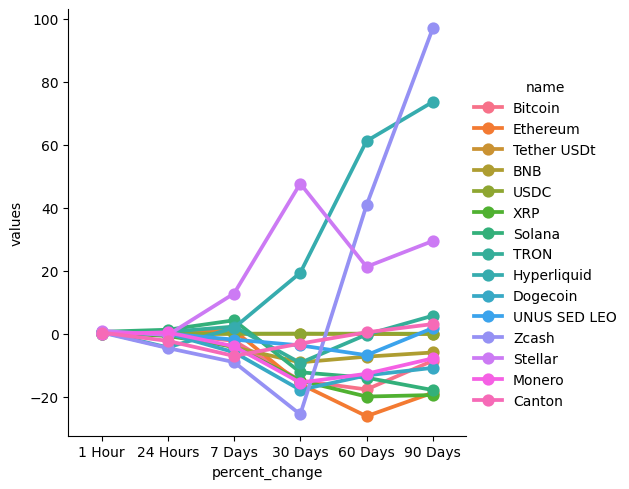

In [51]:
sns.catplot(x='percent_change', y='values', hue='name',data=df7, kind='point')

In [49]:
df7['percent_change'] =df7['percent_change'].replace({'quote.USD.percent_change_1h':'1 Hour',
                               'quote.USD.percent_change_24h':'24 Hours',
                               'quote.USD.percent_change_7d':'7 Days',
                               'quote.USD.percent_change_30d':'30 Days',
                               'quote.USD.percent_change_60d':'60 Days',
                               'quote.USD.percent_change_90d':'90 Days'})

In [50]:
df7

,name,percent_change,values
0,Bitcoin,1 Hour,0.470076
1,Bitcoin,24 Hours,0.043498
2,Bitcoin,7 Days,-2.261627
3,Bitcoin,30 Days,-14.909830
4,Bitcoin,60 Days,-17.688353
5,Bitcoin,90 Days,-8.582877
6,Ethereum,1 Hour,0.235532
7,Ethereum,24 Hours,0.300411
8,Ethereum,7 Days,1.014599
9,Ethereum,30 Days,-15.949183


In [52]:
df10 = df[['name','quote.USD.price','timestamp']]
df10

,name,quote.USD.price,timestamp
0,Bitcoin,64181.643605,2026-06-22 10:19:56.053157
1,Ethereum,1734.498878,2026-06-22 10:19:56.053157
2,Tether USDt,0.998798,2026-06-22 10:19:56.053157
3,BNB,590.279683,2026-06-22 10:19:56.053157
4,USDC,0.999826,2026-06-22 10:19:56.053157
5,XRP,1.135645,2026-06-22 10:19:56.053157
6,Solana,73.981812,2026-06-22 10:19:56.053157
7,TRON,0.327900,2026-06-22 10:19:56.053157
8,Hyperliquid,66.087171,2026-06-22 10:19:56.053157
9,Dogecoin,0.083333,2026-06-22 10:19:56.053157


In [53]:
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp
0,Bitcoin,64181.643605,2026-06-22 10:19:56.053157
15,Bitcoin,64181.643605,2026-06-22 10:19:57.308320
30,Bitcoin,64200.606848,2026-06-22 10:20:58.692938
45,Bitcoin,64200.606848,2026-06-22 10:21:59.518739


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

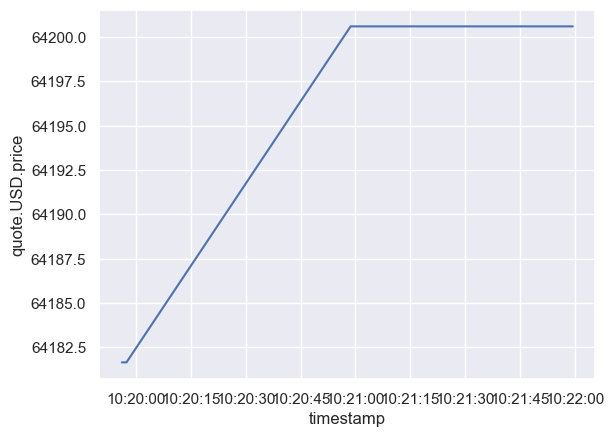

In [55]:
sns.set_theme(style="darkgrid")
sns.lineplot(x='timestamp', y='quote.USD.price', data=df10)